simulation using a fixed transmissibility - beta

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import covasim as cv
from Bio import SeqIO

from covasim.jhk_covasim4wastewater.intervention_search.simulation.runner import run_evo_simulation
from covasim.jhk_covasim4wastewater.intervention_search.analysis.mutation_tree import build_mutation_tree, build_infection_seq_tree, extract_sequenced_subtree, add_internal_leaves, mutation_tree_to_newick, export_fasta_from_G, set_all_branch_lengths_to_one
from covasim.jhk_covasim4wastewater.intervention_search.plotting.plot_mutation_tree import plot_mutation_tree, plot_erase_mutation_tree, plot_phylo_tree

# from covasim.transmission_tree import TransmissionTree
# from covasim.metrics import Metrics
from covasim.inference import Inference

In [29]:
REF_FASTA     = 'sars-2-data/NC_045512_Hu-1.fasta'
FITNESS_CSV   = '../../data/nt_fitness.csv'
ARTIC_PRIMERS = 'sars-2-data/ARTIC_V4-1.bed'
FIG_DIR = "/home/yutianc/covasim4wastewater/docs/tutorials/results"

ay4_fasta   = 'sars-2-data/variants/AY.4_consensus.fasta'
ba2_fasta   = 'sars-2-data/variants/BA.2.9_consensus.fasta'
xbb15_fasta = 'sars-2-data/variants/XBB.1.5.18_consensus.fasta'


In [30]:
ay4 = cv.variant(
    variant        = {},
    label          = 'AY.4',
    days           = 30,
    n_imports      = 60,
    founding_fasta = ay4_fasta,
)
ba2 = cv.variant(
    variant        = {},
    label          = 'BA.2',
    days           = 70,
    n_imports      = 60,
    founding_fasta = ba2_fasta,
)
xbb15 = cv.variant(
    variant        = {},
    label          = 'XBB.1.5',
    days           = 30,
    n_imports      = 10,
    founding_fasta = xbb15_fasta,
)

sample_days = list(range(10, 121, 10))
# Routine clinical: 50 symptomatic agents per day, every 10 days.
cs_routine = cv.ClinicalSequencer(
    days      = sample_days,
    n_samples = 50,
    pool      = 'symptomatic',
    label     = 'CS_routine',
    # sequencing_batch_size defaults to 1, causing immediate release
)

In [31]:
evo_pars = dict(
    enable            = True,
    reference         = REF_FASTA,
    mol_clock_rate    = 7.2e-5, # ~1 substitution/genome/month at 30 000 nt
    sub_model         = 'JC', # decides which mutations happen
    fitness_model = None, # controls transmission rate
    fitness_data_path = FITNESS_CSV,
    store_infection_log=True,
    fitness_scale     = 0.1,
)
sim_pars = dict(
    pop_size=1000,
    pop_type='hybrid',
    pop_infected=10,
    start_day='2021-01-01', 
    n_days=121,
    beta=0.016,
    rand_seed=42,
    verbose=0,    
    variants=[xbb15],
    analyzers=[cs_routine],    
)
policy_pars = dict(
    p_test=0.3,
    p_seq=0.5,
    detection_threshold=3,
    delay_pmf=[0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03],
    quiet_period=0,
)
sim, obs, interv, _, results = run_evo_simulation(sim_pars, evo_pars, policy_pars)

cs_routine = sim.get_analyzer('CS_routine')

/home/yutianc/covasim4wastewater/covasim/clinical.py:194: UserWarning: ClinicalSequencer day 10: requested 50 samples but only 7 agents are available in pool='symptomatic'. Returning all 7 agents.
  warnings.warn(
/home/yutianc/covasim4wastewater/covasim/clinical.py:194: UserWarning: ClinicalSequencer day 20: requested 50 samples but only 11 agents are available in pool='symptomatic'. Returning all 11 agents.
  warnings.warn(
/home/yutianc/covasim4wastewater/covasim/clinical.py:194: UserWarning: ClinicalSequencer day 30: requested 50 samples but only 35 agents are available in pool='symptomatic'. Returning all 35 agents.
  warnings.warn(
/home/yutianc/covasim4wastewater/covasim/clinical.py:194: UserWarning: ClinicalSequencer day 80: requested 50 samples but only 49 agents are available in pool='symptomatic'. Returning all 49 agents.
  warnings.warn(
/home/yutianc/covasim4wastewater/covasim/clinical.py:194: UserWarning: ClinicalSequencer day 90: requested 50 samples but only 28 agents a

Policy B mutation tree: nodes=1051, edges=1050


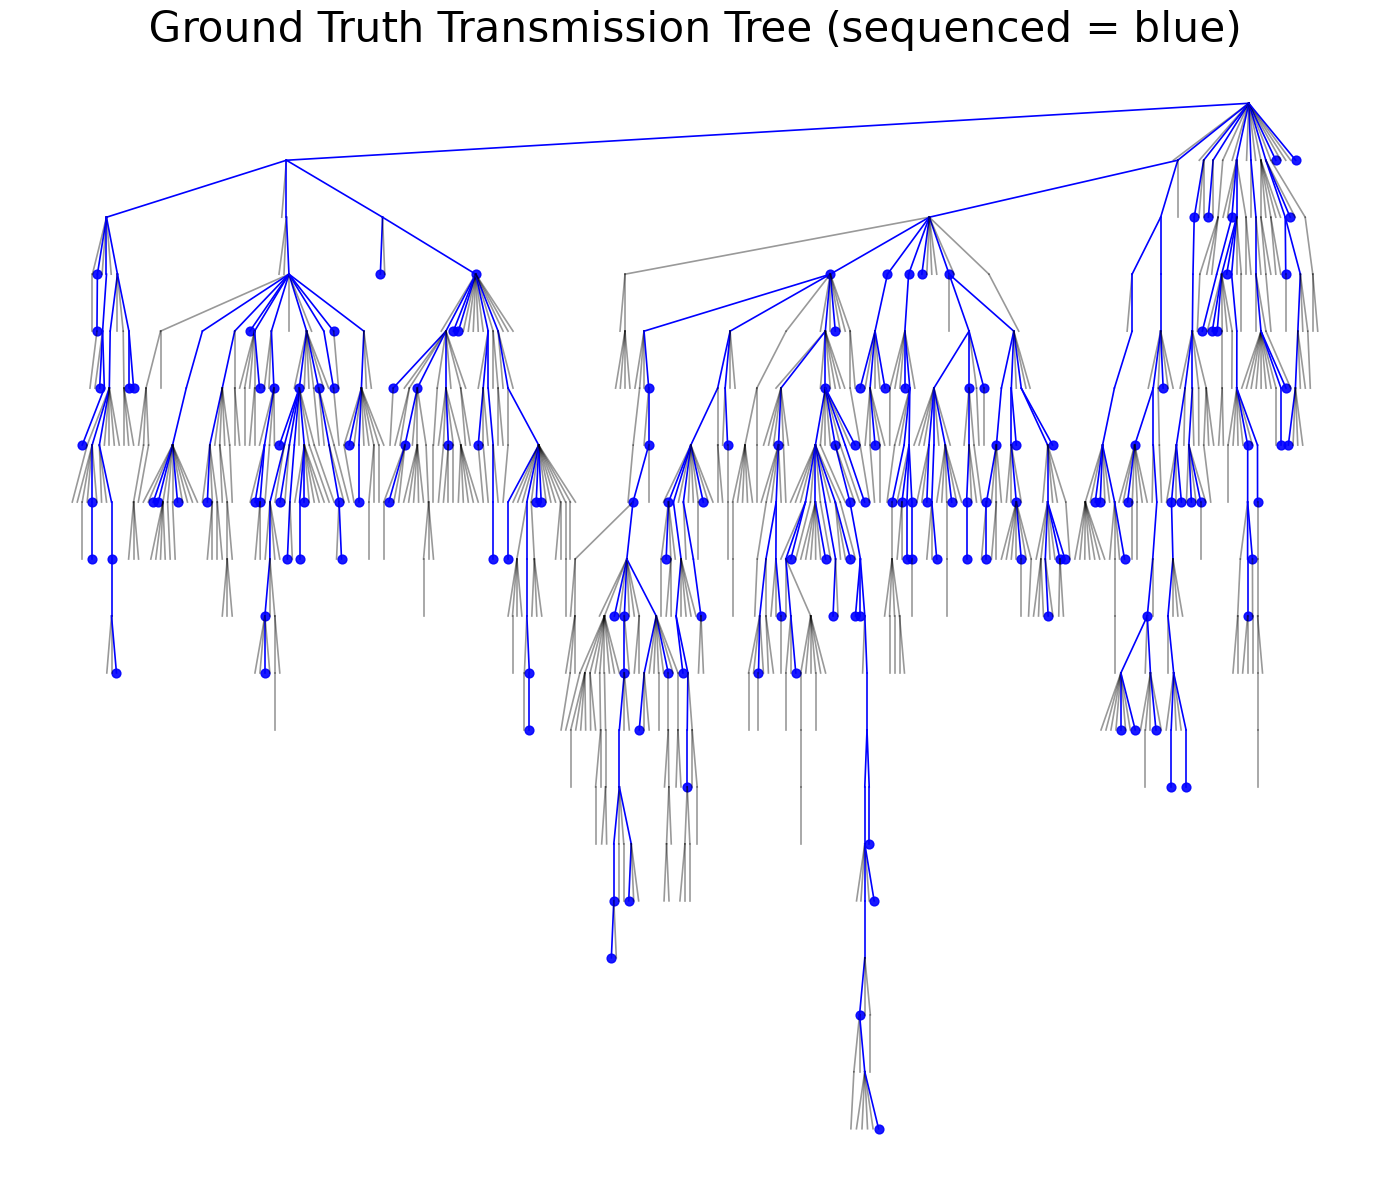

In [32]:
sequenced_agents = set()
for day_list in obs.daily_sequenced_agents:
    sequenced_agents.update(day_list)

G = build_mutation_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G.nodes)}, edges={len(G.edges)}")

plot_erase_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

Policy B mutation tree: nodes=1029, edges=1028


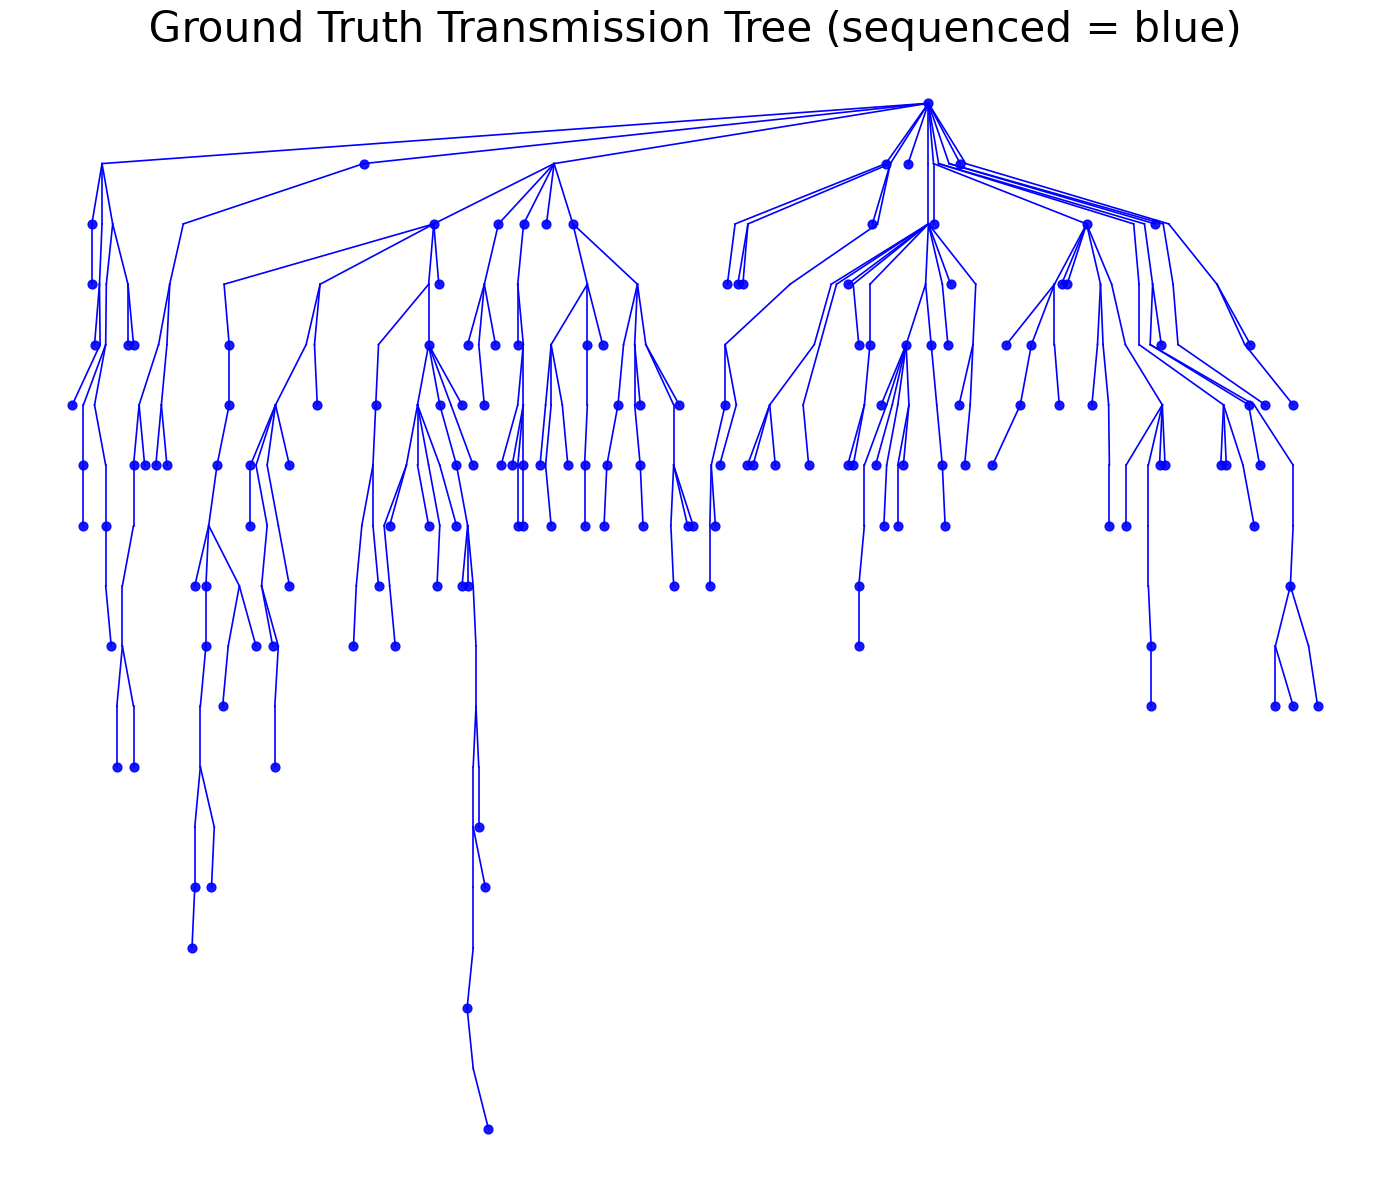

In [33]:
G_infect, mutation_nodes, node_events = build_infection_seq_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G_infect.nodes)}, edges={len(G_infect.edges)}")

plot_erase_mutation_tree(
    G_infect,
    savepath="/home/yutianc/covasim4wastewater/docs/tutorials/results/mutation_tree_policy_seq.png",
    show=True,
    detection_day=None,
    erase=True,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

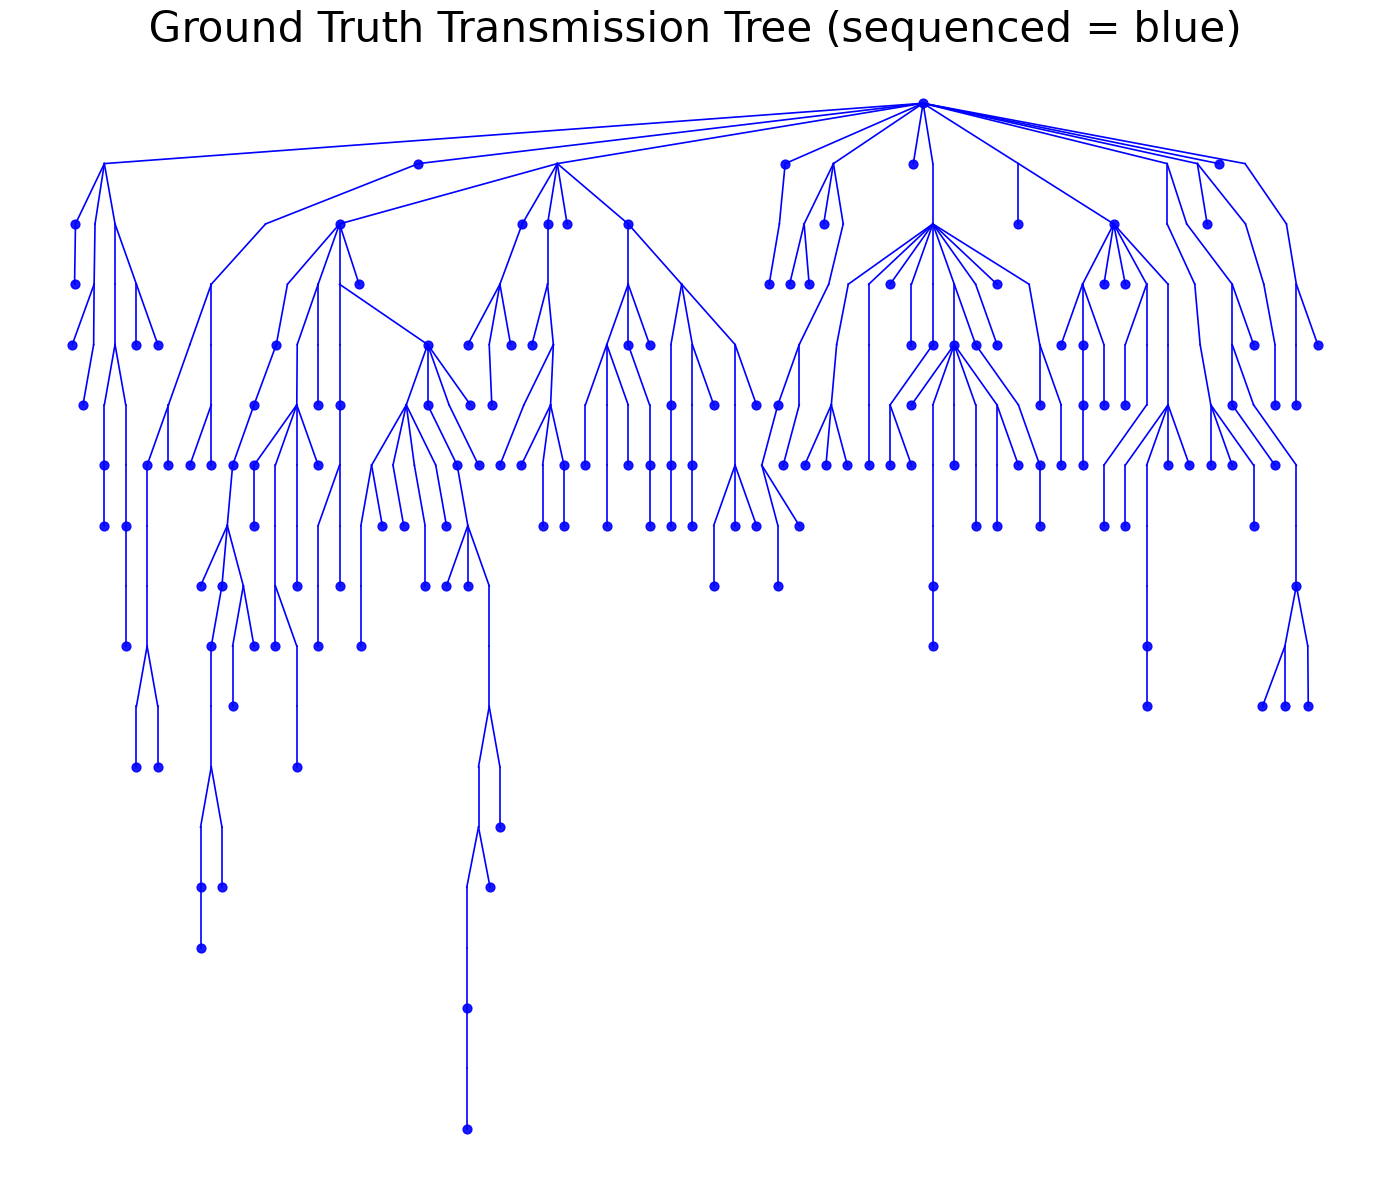

In [34]:
G_prune = extract_sequenced_subtree(G_infect) # the tree will be pruned to the subtree with every node having at least 1 sequecncing event

plot_erase_mutation_tree(
    G_prune,
    savepath="/home/yutianc/covasim4wastewater/docs/tutorials/results/mutation_tree_policy_seq.png",
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

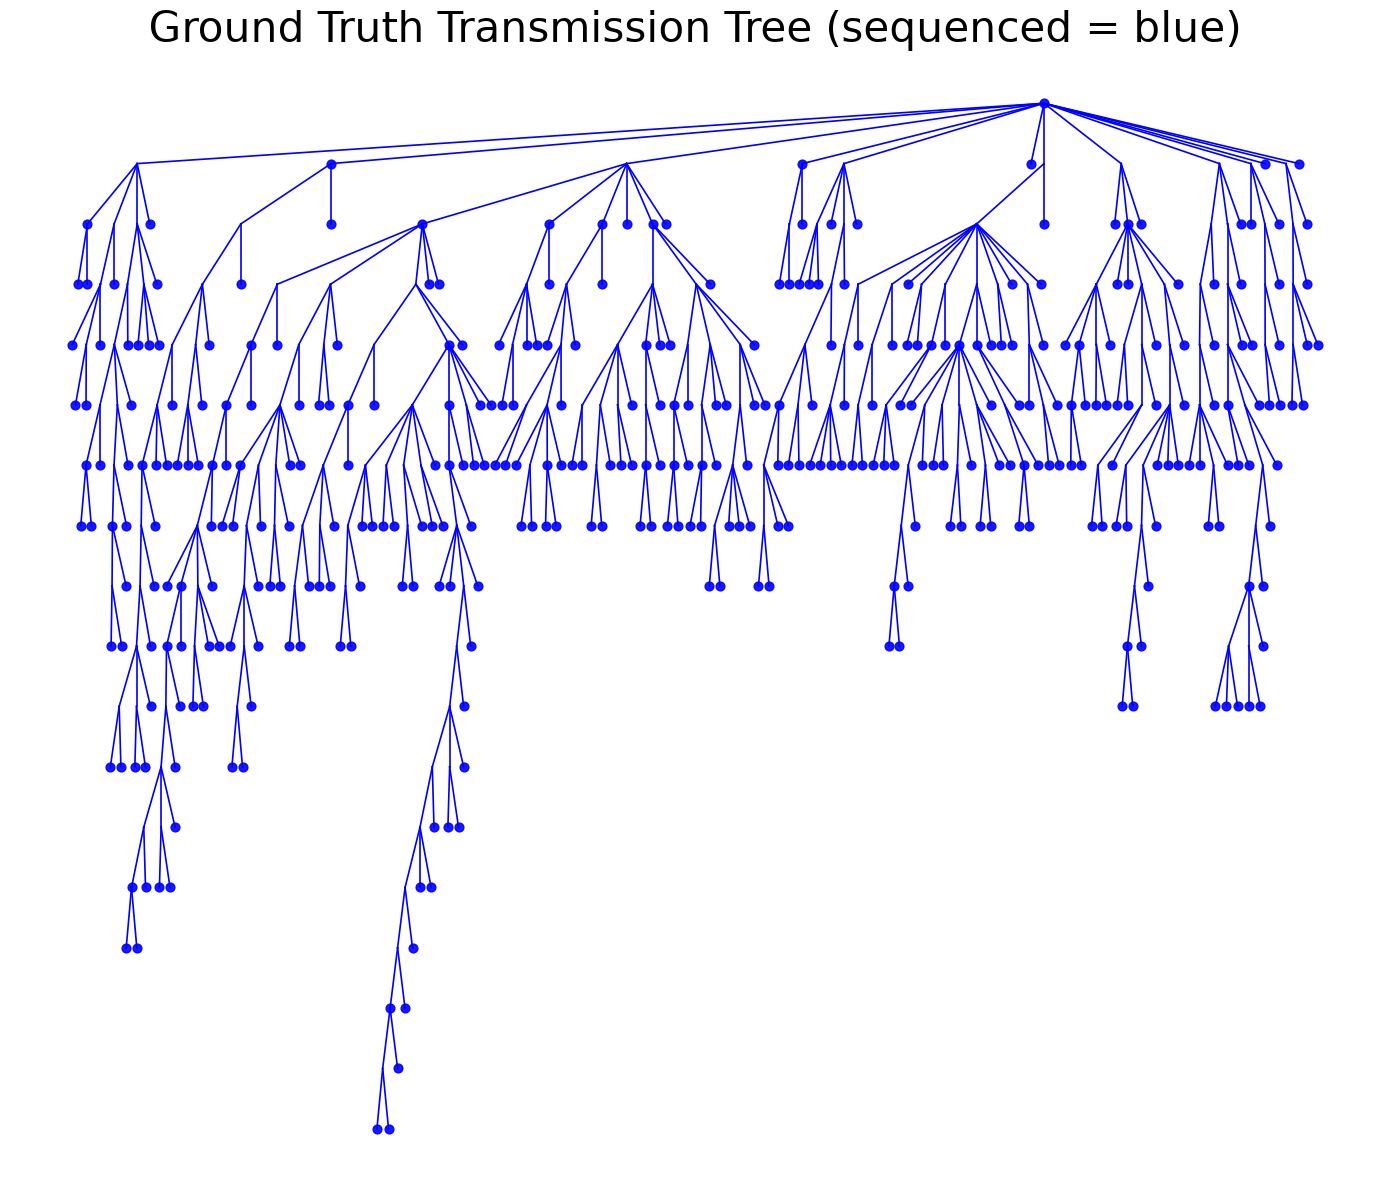

In [35]:
G_prune_leaf = add_internal_leaves(G_prune)
plot_erase_mutation_tree(
    G_prune_leaf,
    savepath=os.path.join(FIG_DIR, "mutation_tree_prune_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

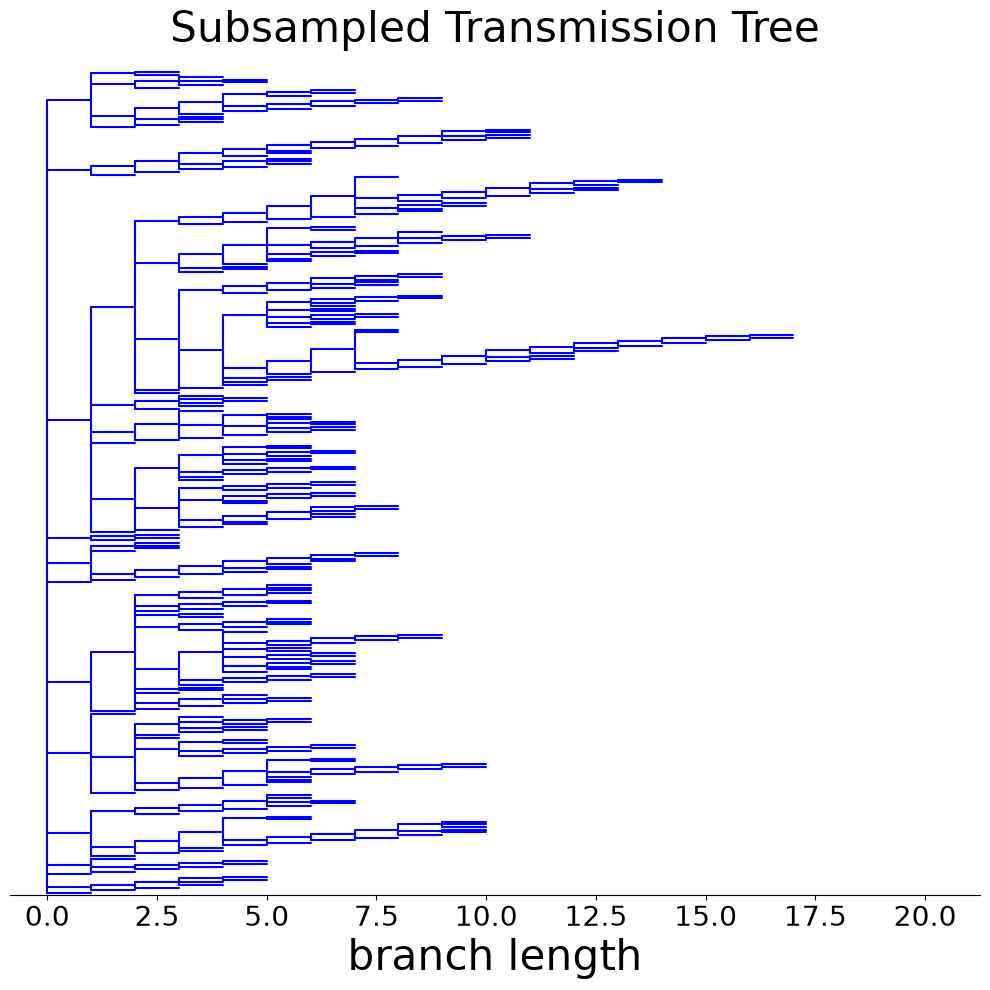

In [36]:
newick_str = mutation_tree_to_newick(G_prune_leaf)

from io import StringIO
from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read(StringIO(newick_str), "newick")

fig = plt.figure(figsize=(10, 10))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    label_func=lambda x: None
)    

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.tick_params(axis='x', labelsize=20)
ax.get_yaxis().set_visible(False)

for coll in ax.collections:
    coll.set_color("blue")
    

plt.title("Subsampled Transmission Tree", fontsize=30, pad=20)
plt.tight_layout()

plt.show()

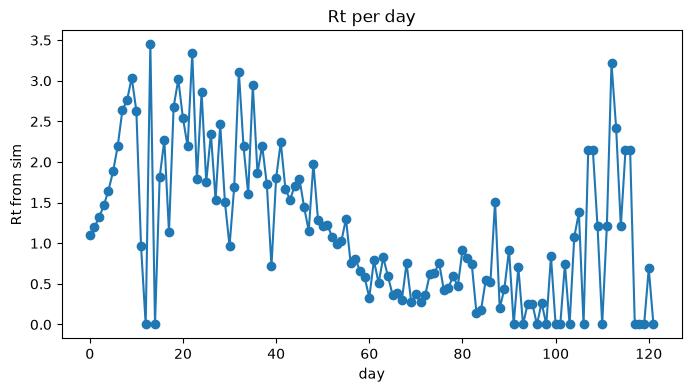

(122,)

In [37]:
# xbb variant is introduced at day30
r = sim.compute_r_eff(method='daily', smoothing=0)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(r)), r, marker="o")
ax.set_xlabel("day")
ax.set_ylabel("Rt from sim")
ax.set_title("Rt per day")
plt.show()
r.shape

In [38]:
print(f"pop_size (actual agents):     {sim['pop_size']}")
print(f"pop_scale:                    {sim['pop_scale']}")
print(f"scaled_pop_size:              {sim.scaled_pop_size}")
print(f"rescale:                      {sim['rescale']}")

# current scale factor at end of sim
print(f"final scale factor:           {sim.rescale_vec[-1]:.1f}")

log    = sim.people.infection_log
n_muts = [e['n_mutations'] for e in log if 'n_mutations' in e]

print(f'Transmission events:    {len(log):,}')
print(f'Mean branch mutations:  {np.mean(n_muts):.3f}')
print(f'Max branch mutations:   {max(n_muts)}')

pop_size (actual agents):     1000
pop_scale:                    1
scaled_pop_size:              1000
rescale:                      True
final scale factor:           1.0
Transmission events:    1,050
Mean branch mutations:  16.431
Max branch mutations:   82


In [39]:
import pandas as pd

def convert_haplotype_tree_to_long_df(mutation_nodes):
    """
    mutation_nodes: {frozenset of (site, ref, alt) -> node_id}
    Returns long-format df with columns: node, site, ref, alt (numeric).
    """
    rows = []
    for mutation_state, node in mutation_nodes.items():
        if not mutation_state:
            rows.append({"node": node, "site": None, "ref": None, "alt": None})
        for site, ref, alt in mutation_state:
            rows.append({"node": node, "site": int(site), "ref": cv.decode_sequence([ref]), "alt": cv.decode_sequence([alt])})
    return pd.DataFrame(rows)

df_mut_full_tree = convert_haplotype_tree_to_long_df(mutation_nodes)

# drop root node - no  mutation
df_mut_full_tree = df_mut_full_tree.dropna()
df_mut_full_tree["site"] = df_mut_full_tree["site"].astype(int)
df_mut_full_tree["mutation"] = df_mut_full_tree["ref"] + df_mut_full_tree["site"].astype(str) + df_mut_full_tree["alt"]
df_mut_full_tree

,node,site,ref,alt,mutation
1,Node_1,27294,A,T,A27294T
2,Node_1,494,G,A,G494A
3,Node_1,1225,A,T,A1225T
4,Node_1,21814,C,G,C21814G
5,Node_1,16256,T,A,T16256A
...,...,...,...,...,...
108347,Node_1028,29514,T,A,T29514A
108348,Node_1028,12853,C,A,C12853A
108349,Node_1028,26501,T,C,T26501C
108350,Node_1028,8670,T,A,T8670A


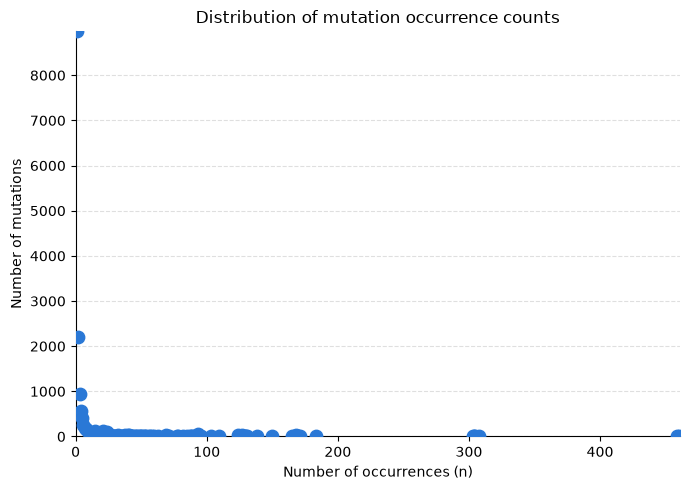

In [40]:
mutation_counts = df_mut_full_tree["mutation"].value_counts()  # counts per individual mutation in full transmission tree
 
n_dist = mutation_counts.value_counts().sort_index()  # index = n, values = number of mutations occurring n times
 
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(n_dist.index, n_dist.values, color="#2a78d6", s=80, zorder=3)
 
ax.set_xlabel("Number of occurrences (n)")
ax.set_ylabel("Number of mutations")
ax.set_title("Distribution of mutation occurrence counts")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.get_major_locator().set_params(integer=True)
ax.yaxis.get_major_locator().set_params(integer=True)
ax.set_xlim(0, n_dist.index.max() + 1)
ax.set_ylim(0, n_dist.values.max() + 2)
ax.grid(axis="y", linestyle="--", alpha=0.4)
 
plt.tight_layout()
plt.show()
 

In [41]:
fitness = pd.read_csv("/home/yutianc/covasim4wastewater/data/nt_fitness.csv")
ref = SeqIO.read("/home/yutianc/covasim4wastewater/docs/tutorials/sars-2-data/NC_045512_Hu-1.fasta", format="fasta")
def get_ref_nt(nt_site):
    return str(ref.seq)[nt_site-1]
fitness["ref"] = fitness["nt_site"].apply(lambda x: get_ref_nt(x))
assert (fitness.loc[(fitness["ref"] == fitness["nt"]) & (fitness["nt_differs_among_clade_founders"] == False), "fitness"] == 0).all()

# some variant with ref == alt has non-zero fitness value, drop them here
fitness = fitness[fitness["nt"] != fitness["ref"]]
fitness["mutation"] = fitness["ref"] + fitness["nt_site"].astype(str) + fitness["nt"]

# variants with the top 10% fitness score. positive value means fitter here
fitness_top10 = fitness.sort_values(by="fitness", ascending=False)[: int(0.1*len(fitness))]
fitness_top10

,nt_site,nt,fitness,expected_count,nt_differs_among_clade_founders,ref,mutation
89727,22786,C,6.26690,302.030,True,A,A22786C
114041,28883,A,6.06910,100.180,True,G,G28883A
73036,18591,G,5.90070,16.822,False,C,C18591G
105606,26766,C,5.17950,11.350,False,A,A26766C
17195,4579,A,5.10530,17.508,False,T,T4579A
...,...,...,...,...,...,...,...
115497,29251,A,0.34784,17.508,False,T,T29251A
47463,12175,A,0.34784,17.508,False,T,T12175A
113329,28705,A,0.34784,17.508,False,T,T28705A
6552,1908,A,0.34784,17.508,False,T,T1908A


In [42]:
# see how many times the top variants show up in the full transmission tree
m = pd.merge(df_mut_full_tree, fitness, on="mutation", how="inner")
out = (
    m.groupby("mutation", as_index=False)
      .agg(counts=("mutation", "count"),     
           fitness=("fitness", "first")) 
)


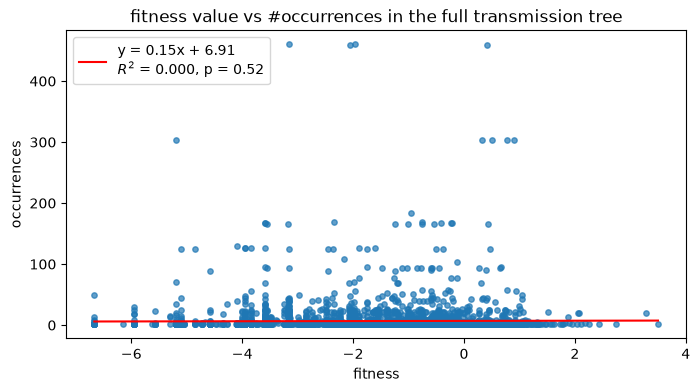

In [43]:
from scipy import stats
cutoff = 0
sub = out[out["counts"] > cutoff].dropna(subset=["fitness", "counts"])
x, y = sub["fitness"].to_numpy(), sub["counts"].to_numpy()

res = stats.linregress(x, y)
xs = np.linspace(x.min(), x.max(), 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y, s=15, alpha=0.7)
ax.plot(xs, res.intercept + res.slope * xs, color="red",
        label=f"y = {res.slope:.2f}x + {res.intercept:.2f}\n$R^2$ = {res.rvalue**2:.3f}, p = {res.pvalue:.2g}")
ax.set_xlabel("fitness")
ax.set_ylabel("occurrences")
ax.set_title("fitness value vs #occurrences in the full transmission tree")
ax.legend()
plt.show()

In [45]:
fasta_path = "/home/yutianc/covasim4wastewater/docs/tutorials/results/polytomy_test_beta.fasta"
export_fasta_from_G(G_prune, sim, fasta_path)

iqtree_inference = Inference(
    fasta_path=fasta_path,
    prefix="inferred_tree_beta", 
    model="JC",
)
iqtree_inference.run_iqtree_asr()


Running: /home/yutianc/miniforge3/envs/covasim4ww/bin/iqtree -s /home/yutianc/covasim4wastewater/docs/tutorials/results/polytomy_test_beta.fasta -m JC -asr -redo -pre inferred_tree_beta
IQ-TREE version 3.1.3 for Linux x86 64-bit built Jul 26 2026
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    profchaos.scripps.edu (AVX512, FMA3, 754 GB RAM)
Command: /home/yutianc/miniforge3/envs/covasim4ww/bin/iqtree -s /home/yutianc/covasim4wastewater/docs/tutorials/results/polytomy_test_beta.fasta -m JC -asr -redo -pre inferred_tree_beta
Seed:    603061 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Fri Oct  2 09:44:46 2026
Kernel:  AVX+FMA - 1 threads (384 CPU cores detected)

HINT: Use -nt option to specify number of threads because your CPU has 384 cores!
HINT: -nt AUTO will automatically determine the best number of thr

In [49]:
from ete3 import Tree
from collections import defaultdict

def sanity_check(tree, node_seqs):
    tree_names = {n.name for n in tree.traverse() if n.name}
    state_names = set(node_seqs.keys())
    only_in_tree = tree_names - state_names
    only_in_state = state_names - tree_names
    print(f"Nodes in tree:  {len(tree_names)}")
    print(f"Nodes in state: {len(state_names)}")
    if only_in_tree:
        print(f"  In tree but not .state ({len(only_in_tree)}): {sorted(only_in_tree)[:10]}")
    if only_in_state:
        print(f"  In .state but not tree ({len(only_in_state)}): {sorted(only_in_state)[:10]}")
    if not only_in_tree and not only_in_state:
        print("  All node names match. \u2713")
        
def load_state_file(state_path):
    node_seqs = defaultdict(dict)
    with open(state_path) as f:
        header = None
        for line in f:
            line = line.rstrip("\n")
            if not line or line.startswith("#"):
                continue
            fields = line.split("\t")
            if header is None:
                header = fields
                continue
            row = dict(zip(header, fields))
            node_seqs[row["Node"]][int(row["Site"])] = row["State"]
    return node_seqs

def load_tip_sequences(fasta_path):
    from Bio import SeqIO
    tip_seqs = {}
    for record in SeqIO.parse(fasta_path, "fasta"):
        tip_seqs[record.id] = {i + 1: base for i, base in enumerate(str(record.seq))}
    return tip_seqs

iqtree = Tree("/home/yutianc/covasim4wastewater/docs/tutorials/inferred_tree_beta.treefile", format=1)
nodes = load_state_file("/home/yutianc/covasim4wastewater/docs/tutorials/inferred_tree_beta.state") # every site for every node
tips = load_tip_sequences("/home/yutianc/covasim4wastewater/docs/tutorials/results/polytomy_test_beta.fasta")
nodes.update(tips)
sanity_check(iqtree, nodes)

Nodes in tree:  624
Nodes in state: 624
  All node names match. ✓


In [50]:
def get_mutations(parent_seq, child_seq):
    muts = []
    for site, ref_state in parent_seq.items():
        alt_state = child_seq.get(site)
        if alt_state is not None and alt_state != ref_state:
            muts.append((site, ref_state, alt_state))
    return sorted(muts)

def compute_edge_mutations(tree, node_seqs):
    edge_mutations = {}
    for node in tree.traverse("preorder"): # root to tips
        if node.is_root() or not node.name:
            continue
        parent = node.up
        if parent.name in node_seqs and node.name in node_seqs:
            edge_mutations[node.name] = get_mutations(
                node_seqs[parent.name], node_seqs[node.name] # get the variants
            )
        else:
            edge_mutations[node.name] = []
    return edge_mutations

def compute_cumulative_mutations(tree, edge_mutations):
    cumulative = {}
 
    def recurse(node, parent_cumulative):
        current = frozenset() if node.is_root() else parent_cumulative | set(
            edge_mutations.get(node.name, [])
        )
        if node.name:
            cumulative[node.name] = frozenset(current)
        for child in node.children:
            recurse(child, current)
 
    recurse(tree, frozenset())
    return cumulative

In [51]:
def convert_sample_tree_to_long_df(mut_dict):
    rows = []
    for node, muts in mut_dict.items():
        if not muts:
            rows.append({"node": node, "site": None, "ref": None, "alt": None})
        for site, ref, alt in muts:
            rows.append({"node": node, "site": int(site), "ref": ref, "alt": alt})

    df = pd.DataFrame(rows)
    return df

edge_mut = compute_edge_mutations(iqtree, nodes)
cumultative_mut = compute_cumulative_mutations(iqtree, edge_mut)

df_mut_sampled_tree = convert_sample_tree_to_long_df(cumultative_mut)
# drop root node
df_mut_sampled_tree = df_mut_sampled_tree.dropna()
df_mut_sampled_tree["site"] = df_mut_sampled_tree["site"].astype(int)
df_mut_sampled_tree["mutation"] = df_mut_sampled_tree["ref"] + df_mut_sampled_tree["site"].astype(str) + df_mut_sampled_tree["alt"]
df_mut_sampled_tree

,node,site,ref,alt,mutation
4,Node4,8294,T,A,T8294A
5,Node4,21815,C,G,C21815G
6,Node4,19420,T,A,T19420A
7,Node4,495,G,A,G495A
8,Node4,29029,T,A,T29029A
...,...,...,...,...,...
55575,Node_195,24339,A,C,A24339C
55576,Node_195,28190,A,G,A28190G
55577,Node_195,15998,C,A,C15998A
55578,Node_195,15637,A,C,A15637C


In [ ]:
# full_tree: node is the node id in the graph, each representing a halplotype (mutation state)
# inference tree: node is the internal node constructed by iqtree inference

cutoff = 0
full_tree_mut_counts = pd.DataFrame(mutation_counts.items(), columns=["mutation", "counts"])
full_tree_mut_counts = full_tree_mut_counts[full_tree_mut_counts["counts"] >= cutoff]

df_mut_sampled_tree = df_mut_sampled_tree.drop_duplicates(subset=["mutation"]) # node is the internal node constructed by iqtree inference
common = pd.merge(full_tree_mut_counts, df_mut_sampled_tree, how="inner", on=["mutation"])

print("number of unique mutations in full tree:", len(full_tree_mut_counts))
print("number of unique mutations captured by inference tree:", len(common))

number of unique mutations in full tree: 15734
number of unique mutations captured by inference tree: 249


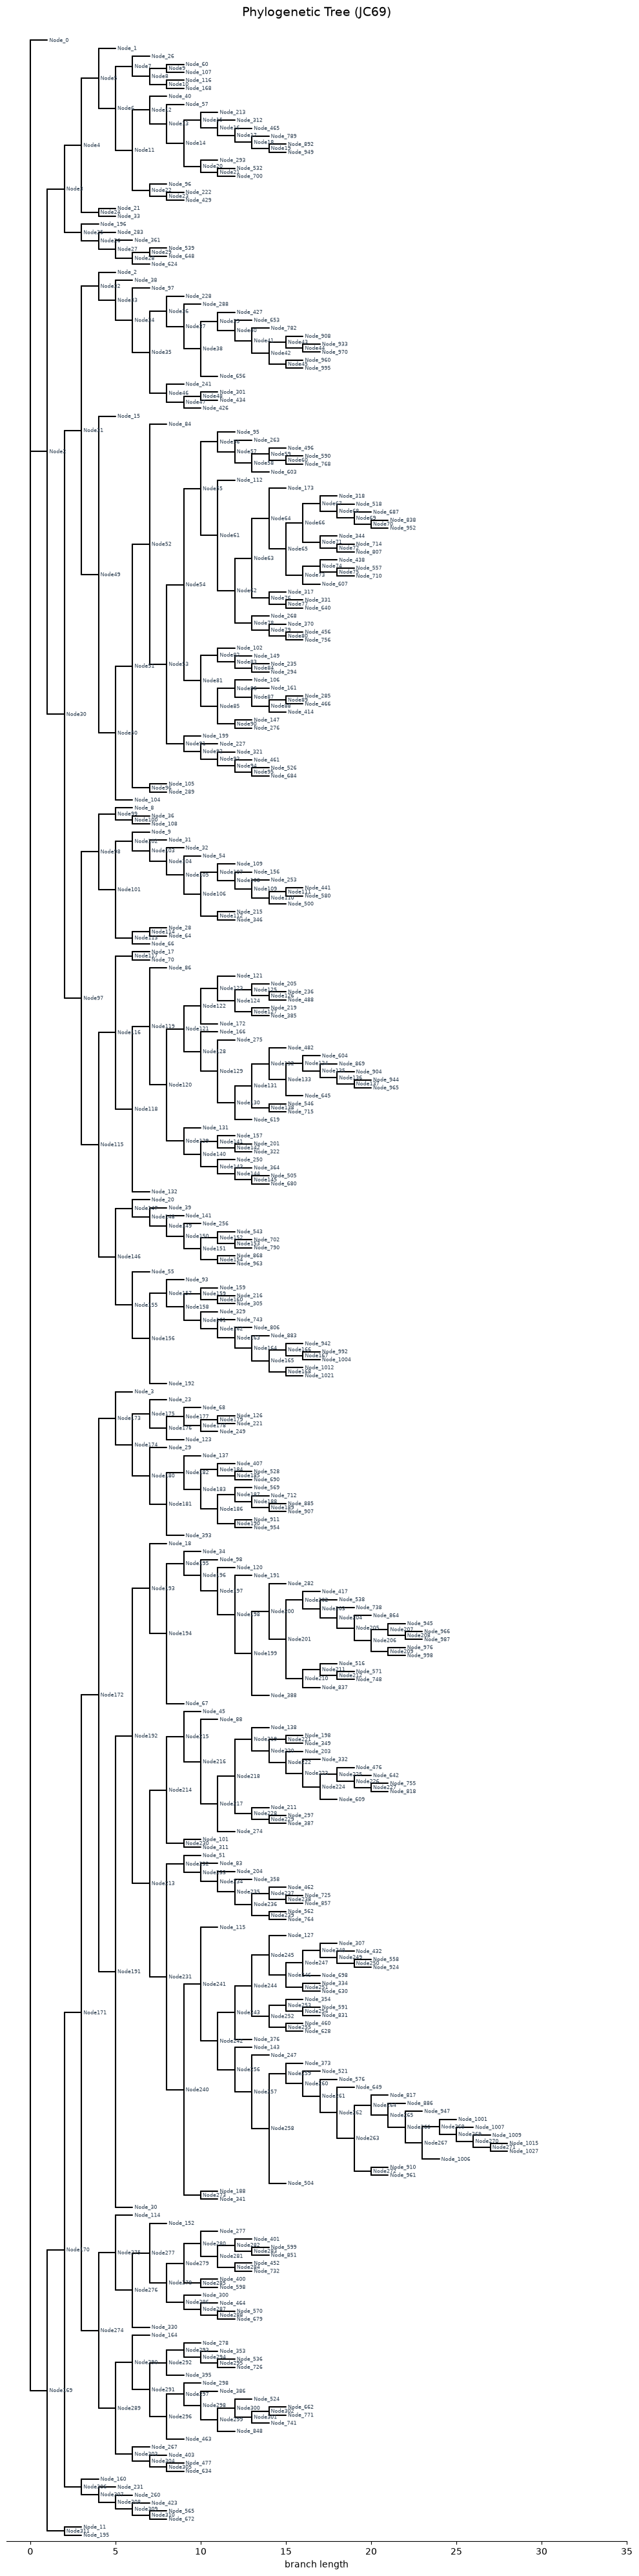

In [54]:
newick_bl1_path = set_all_branch_lengths_to_one("/home/yutianc/covasim4wastewater/docs/tutorials/inferred_tree_beta.treefile")
plot_phylo_tree(newick_bl1_path, savepath=None)

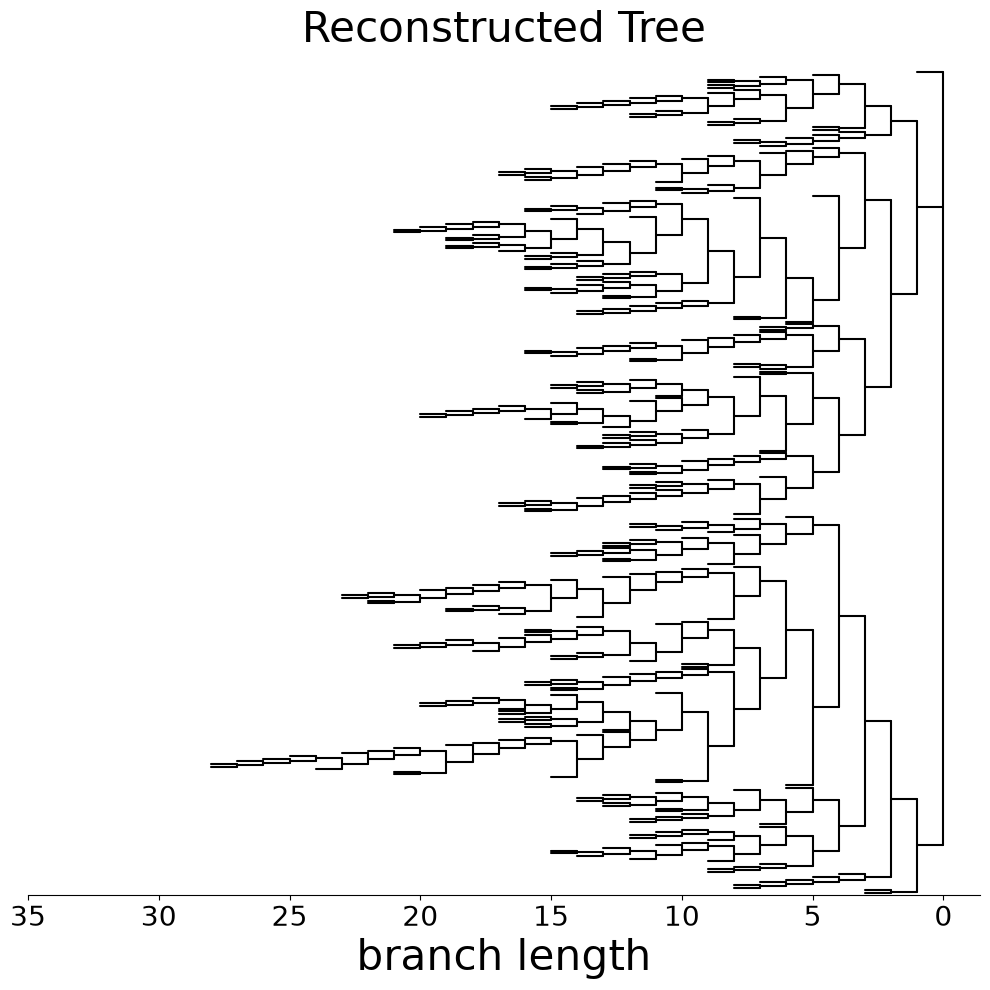

In [55]:
tree = Phylo.read(newick_bl1_path, "newick")

fig = plt.figure(figsize=(10, 10))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    label_func=lambda x: None
)
ax.invert_xaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.tick_params(axis='x', labelsize=20)
ax.get_yaxis().set_visible(False)

plt.title("Reconstructed Tree", fontsize=30, pad=20)
plt.tight_layout()
plt.show()


crossings before: 23279
crossings after:  0


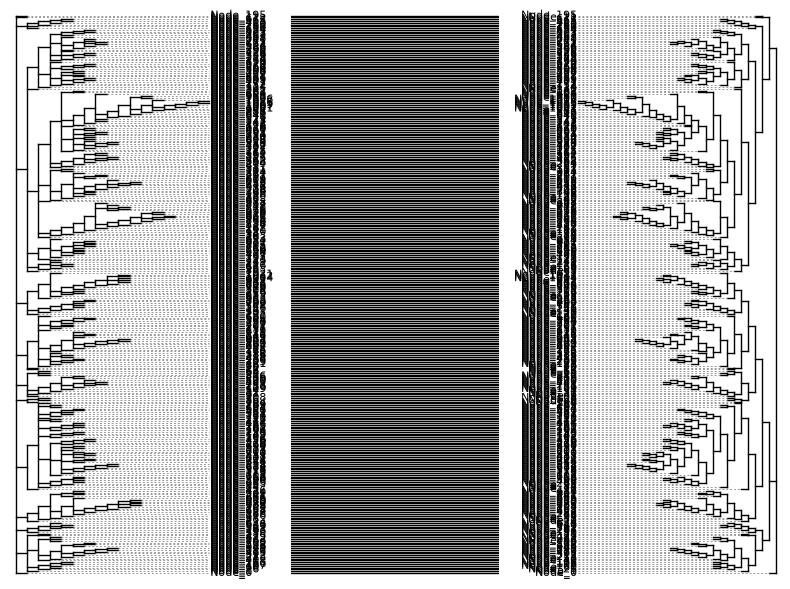

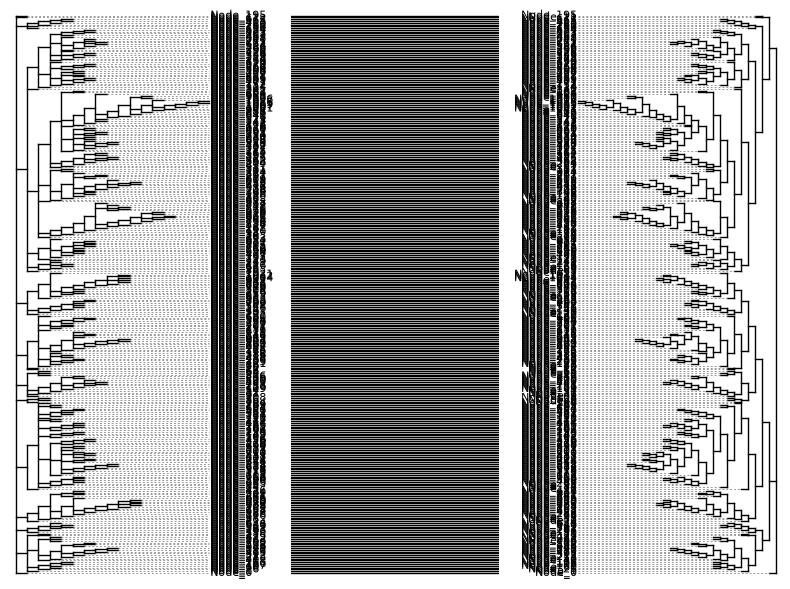

In [57]:
from covasim.jhk_covasim4wastewater.intervention_search.cophylogeny.polytomy_tanglegram import run_polytomy_tanglegram

run_polytomy_tanglegram(newick_str, newick_bl1_path)